# Tutorial 3 — JWST/NIRCam coronagraphy: HIP 65426 b with ADI + RDI (pyKLIP engine)

The ERS-1386 NIRCam observations of HIP 65426 (Carter et al. 2023) are the reference
JWST high-contrast data set: two science rolls through the MASK335R coronagraph and a
reference star (HIP 68245) observed in a 9-point small-grid dither.  With only ~10° of
roll this is an **RDI** problem — what matters is how the 18 reference frames are used,
not the field rotation.

spaceKLIP is the community pipeline for these data and hands them to pyKLIP; klip-tpe
plugs in at that hand-over: one partition per roll, the reference exposures as the RDI
library, pyKLIP's `klip_parallelized` as the engine, and the TPE search on top.

**Data.**  `tutorials/fetch_jwst_hip65426.py` pulls the F444W `calints` products from
MAST (no login, ~60 MB):
```
python3 -m pip install astroquery pyklip
python3 tutorials/fetch_jwst_hip65426.py            # --dry-run lists the files first
```
The notebook skips the run (and says so) when the files are not there.

In [1]:
import glob, os, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe.reducer import Dataset, ReductionRequest
from klip_tpe.backends import spaceklip as sk
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay
from klip_tpe.metrics import MawetPeakSNR

DATA = os.path.expanduser(os.environ.get("KLIP_TPE_JWST", "~/.klip_tpe/data/jwst_hip65426"))
RUN_DIR = os.path.abspath("runs/hip65426_f444w")
PLANET = (0.826, 150.2)                    # HIP 65426 b, Carter et al. 2023

files = sorted(glob.glob(os.path.join(DATA, "**", "jw*calints.fits"), recursive=True))
def _targ(f):
    h = fits.getheader(f)
    return str(h.get("TARGPROP", h.get("TARGNAME", ""))).replace("-", "").replace("_", "").upper()
sci_files = [f for f in files if _targ(f).startswith("HIP65426")]
ref_files = [f for f in files if f not in sci_files]
HAVE_DATA = len(sci_files) >= 2 and len(ref_files) >= 1
print(f"science exposures: {len(sci_files)}, reference exposures: {len(ref_files)}"
      f"  ({'ok' if HAVE_DATA else 'data not found - run the fetch script'})")

science exposures: 2, reference exposures: 9  (ok)


## 1. Stage-2 products need cleaning and alignment first

`*_calints.fits` come out of the JWST calibration pipeline *uncleaned*: hot and dead
pixels are flagged in the `DQ` extension but not repaired, and nothing has been aligned —
each small-grid-dither reference exposure sits at its own sub-pixel offset.  Subtracting
such references leaves a residual far brighter than any planet (try it: the planet is
undetectable without this section).

**In production, use spaceKLIP's `ImageTools`** (`quick_cleaning`, `align_frames`, …),
which does this properly and writes `STARCENX/Y` into the headers; `load_spaceklip` then
reads its products directly (section 6).  So that this notebook stands alone, here is the
minimal version: repair the flagged and outlying pixels, then register every frame on the
median science frame by FFT cross-correlation.

4 science integrations at PA [110.3 120.4] deg, 18 reference integrations, 320x320 px


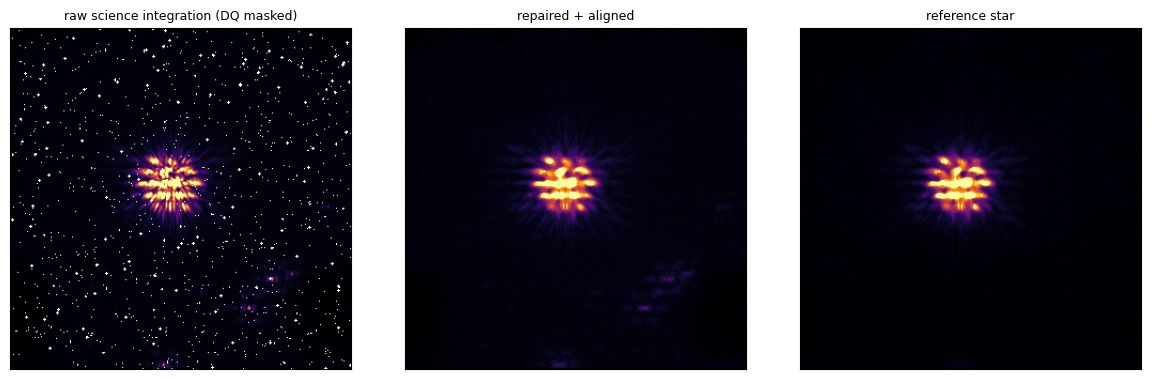

In [2]:
def read_calints(paths):
    """(frames, position angles) from stage-2 products; DQ=DO_NOT_USE pixels -> NaN."""
    ims, pas = [], []
    for f in paths:
        with fits.open(f) as h:
            d = np.asarray(h["SCI"].data, float)
            dq = np.asarray(h["DQ"].data, int) if "DQ" in h else np.zeros_like(d, int)
            s = h["SCI"].header
            pa = float(s["ROLL_REF"]) - float(s.get("V3I_YANG", 0.0)) * float(s.get("VPARITY", 1))
            d = np.where((dq & 1).astype(bool), np.nan, d)          # bit 0 = DO_NOT_USE
            for i in range(d.shape[0]):                             # one entry per integration
                ims.append(d[i]); pas.append(pa)
    return np.array(ims), np.array(pas)

def repair(cube, size=5, nsig=7.0):
    """Replace flagged pixels and >nsig outliers by the local median."""
    out = np.array(cube, float)
    for i, im in enumerate(out):
        bad = ~np.isfinite(im)
        med = ndimage.median_filter(np.where(bad, np.nanmedian(im), im), size=size)
        res = np.abs(im - med)
        s = 1.4826 * np.nanmedian(np.abs(res - np.nanmedian(res)))
        out[i] = np.where(bad | (res > nsig * s), med, im)
    return out

def xcorr_shift(im, ref, search=6):
    """Sub-pixel (dx, dy) that brings `im` onto `ref` (FFT cross-correlation + parabola)."""
    cc = np.fft.fftshift(np.fft.irfft2(np.fft.rfft2(im) * np.conj(np.fft.rfft2(ref)), s=im.shape))
    c = np.array(im.shape) // 2
    sub = cc[c[0] - search:c[0] + search + 1, c[1] - search:c[1] + search + 1]
    k = np.unravel_index(np.argmax(sub), sub.shape)
    dy, dx = k[0] - search, k[1] - search
    par = lambda a, b, c_: 0.0 if (a - 2 * b + c_) == 0 else 0.5 * (a - c_) / (a - 2 * b + c_)
    if 0 < k[0] < sub.shape[0] - 1: dy += par(sub[k[0] - 1, k[1]], sub[k[0], k[1]], sub[k[0] + 1, k[1]])
    if 0 < k[1] < sub.shape[1] - 1: dx += par(sub[k[0], k[1] - 1], sub[k[0], k[1]], sub[k[0], k[1] + 1])
    return dx, dy

def align(cube, ref):
    out = np.empty_like(cube)
    for i, im in enumerate(cube):
        dx, dy = xcorr_shift(im, ref)
        out[i] = ndimage.shift(im, (-dy, -dx), order=3, mode="constant", cval=0.0)
    return out

if HAVE_DATA:
    sci_raw, pas = read_calints(sci_files)
    ref_raw, _ = read_calints(ref_files)
    print(f"{sci_raw.shape[0]} science integrations at PA {np.unique(np.round(pas, 1))} deg, "
          f"{ref_raw.shape[0]} reference integrations, {sci_raw.shape[1]}x{sci_raw.shape[2]} px")
    sci_c, ref_c = repair(sci_raw), repair(ref_raw)
    anchor = np.median(sci_c, axis=0)
    sci_a, ref_a = align(sci_c, anchor), align(ref_c, anchor)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
    for a, im, t in zip(ax, (sci_raw[0], sci_a[0], ref_a[0]),
                        ("raw science integration (DQ masked)", "repaired + aligned", "reference star")):
        v = np.nanpercentile(im[np.isfinite(im)], [5, 99.5])
        a.imshow(im, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1]); a.set_title(t, fontsize=9)
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()

## 2. Partitions: one per roll, references as the RDI library

The star sits on the coronagraph reference pixel (`CRPIX`; spaceKLIP products carry the
measured `STARCENX/Y`), so the crop is taken about it — klip-tpe expects the star at the
centre of the array.  Each roll becomes a `Dataset` with its own parameter block, and both
carry the same reference cube.

In [3]:
if HAVE_DATA:
    hdr = fits.getheader(sci_files[0], "SCI")
    pxscale = float(np.sqrt(hdr["PIXAR_A2"]))                      # 0.0626"/px (NIRCam LW)
    wavelength = 4.44e-6                                           # F444W pivot
    cx, cy = hdr["CRPIX1"] - 1.0, hdr["CRPIX2"] - 1.0              # 0-based star pixel
    H = 55                                                          # 110x110 px = 6.9" square

    def crop(cube):
        fx, fy = cx - round(cx), cy - round(cy)
        x0, y0 = int(round(cx)) - H, int(round(cy)) - H
        return np.array([ndimage.shift(im, (-fy, -fx), order=3)[y0:y0 + 2 * H, x0:x0 + 2 * H]
                         for im in cube], np.float32)

    sci_x, ref_x = crop(sci_a), crop(ref_a)
    dsets = {}
    for k, pa in enumerate(np.unique(np.round(pas, 1))):
        m = np.round(pas, 1) == pa
        dsets[f"roll{k + 1}"] = Dataset(sci_x[m], pas[m], name=f"roll{k + 1}", ref_cube=ref_x,
                                        meta={"pxscale": pxscale, "wavelength_m": wavelength})
    for pid, d in dsets.items():
        print(f"{pid}: {d.cube.shape[0]} integrations, PA {d.angles[0]:.1f} deg, "
              f"RDI library {d.ref_cube.shape[0]} frames")

roll1: 2 integrations, PA 110.3 deg, RDI library 18 frames
roll2: 2 integrations, PA 120.4 deg, RDI library 18 frames


## 3. Reducer, space, objective

`spaceklip.make_reducer` builds one `PyKLIPReducer` per partition, with λ/D from the
filter and D = 6.5 m.  The searched block per roll is small here — the high-pass filter,
`n_ang` (pyKLIP `subsections`) and `k_klip` (`numbasis`) — because `make_space` scales the
ranges to the data: with two integrations per roll there is nothing to bin and no angular
exclusion worth searching.

On top of that we add one *global categorical* dimension: pyKLIP's **`mode`**
(`ADI`, `RDI`, `ADI+RDI`).  Any `Param` whose name matches a backend option is passed
straight through to the engine, so the optimizer can decide how to use the reference
library — and with a 10° roll that decision matters: in `ADI+RDI` the other roll enters
the basis at ~1 FWHM of planet motion and eats the companion, while pure `RDI` keeps it.

For calibrated contrasts the injection template should be a webbpsf / `webbpsf_ext`
off-axis PSF (`psf_template=`, e.g. from spaceKLIP's `analysistools.get_offsetpsf`) with
the star's measured flux (`star_flux=`).  Without one, a Gaussian of 1.028 λ/D and flux
unit 1 is used: parameter *ranking* is unaffected, only the contrast axis is arbitrary.

In [4]:
PSF_TEMPLATE = os.path.join(DATA, "offset_psf_F444W.fits")
PSF_TEMPLATE = PSF_TEMPLATE if os.path.exists(PSF_TEMPLATE) else None
STAR_FLUX = None
if HAVE_DATA:
    from klip_tpe import Param
    red = sk.make_reducer(dsets, psf_template=PSF_TEMPLATE, star_flux=STAR_FLUX, mode="RDI",
                          max_workers="auto")          # pool="threads": pyKLIP forks its own workers
    space = generic.make_space(red, k_klip_max=18, search_angles=False)
    space.add(Param("mode", 0, 2, "categorical", choices=["ADI", "RDI", "ADI+RDI"], default="RDI",
                    doc="pyKLIP PSF-subtraction mode"))
    space.project = generic.make_guard(red, k_max=18, n_min_ref=4)
    objective, sampler = generic.default_config(red, known=[PLANET])
    print(space.names)

  roll1: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection gaussian
  roll2: pyklip RDI, lambda/D 2.25 px, fwhm 2.31 px, injection gaussian
['bin_roll1', 'n_ang_roll1', 'filter_roll1', 'k_klip_roll1', 'bin_roll2', 'n_ang_roll2', 'filter_roll2', 'k_klip_roll2', 'drop1', 'drop2', 'mode']


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A default RDI reduction with 10 KL modes: HIP 65426 b is the point source at 0.83″,
PA 150° (circled).  (Try `mode="ADI+RDI"` here to see the companion disappear.)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 81.27it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 248.05it/s]

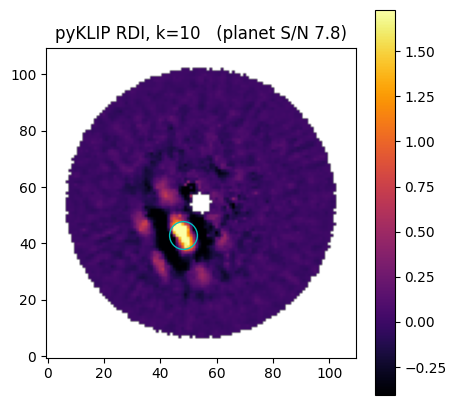

In [5]:
if HAVE_DATA:
    cfg0 = space.decode(space.default_vector())
    res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=6, outrad=45, k_klip=10, mode="RDI")))
    metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)
    c = (res.image.shape[0] - 1) / 2.0
    xb = c - PLANET[0] / pxscale * np.sin(np.deg2rad(PLANET[1]))
    yb = c + PLANET[0] / pxscale * np.cos(np.deg2rad(PLANET[1]))
    snr0 = float(metric.per_source(res.image, None, [PLANET[0]], [PLANET[1]])[0])
    plt.figure(figsize=(5, 5)); v = np.nanpercentile(res.image[np.isfinite(res.image)], [2, 99.7])
    plt.imshow(res.image, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1])
    plt.plot(xb, yb, "o", mfc="none", mec="c", ms=20); plt.colorbar()
    plt.title(f"pyKLIP RDI, k=10   (planet S/N {snr0:.1f})")

In [6]:
if HAVE_DATA:                                    # the same reduction in ADI+RDI: the roll pair self-subtracts
    for m in ("ADI", "RDI", "ADI+RDI"):
        im = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=6, outrad=45, k_klip=10, mode=m))).image
        print(f"mode={m:8s} planet S/N {float(metric.per_source(im, None, [PLANET[0]], [PLANET[1]])[0]):5.1f}")

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 283.67it/s]


100%|██████████| 2/2 [00:00<00:00, 160.46it/s]

mode=ADI      planet S/N   0.0


...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 204.73it/s]


100%|██████████| 2/2 [00:00<00:00, 134.96it/s]

mode=ADI+RDI  planet S/N   1.7


## 4. Optimize

50 evaluations, the best two validated on three fresh injection sets each.  Each
evaluation injects companions into the *science* frames only — the reference library is
never contaminated — reduces with and without them and scores the difference.

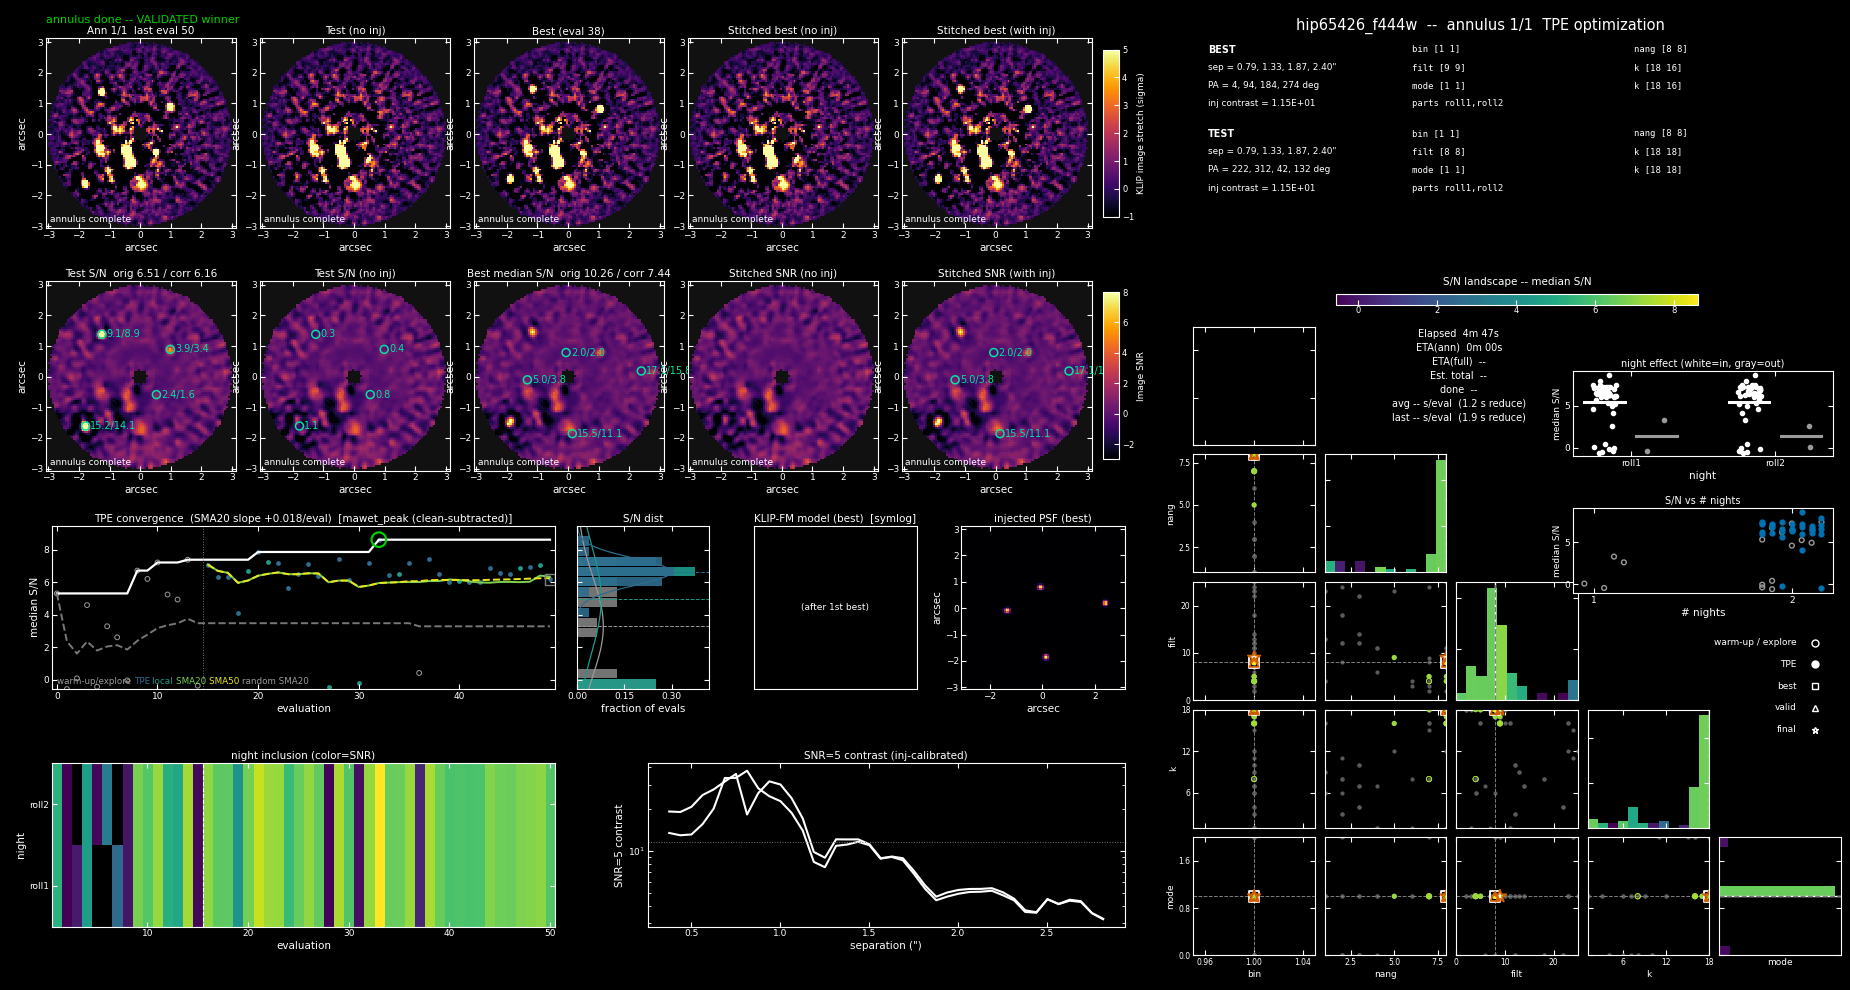

=== annulus 1/1: [6.0, 45.0] px, 4 sources, band 0.520-2.672"


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 50.23it/s]


100%|██████████| 2/2 [00:00<00:00, 51.78it/s]

...

/home/claude/klip-tpe-py/klip_tpe/display.py:1279: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[i], hi[i])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])


/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])


/home/claude/klip-tpe-py/klip_tpe/display.py:1279: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[i], hi[i])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])
/home/claude/klip-tpe-py/klip_tpe/display.py:1256: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo[j], hi[j])


run complete: 1 annuli, 50 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/hip65426_f444w/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/hip65426_f444w/opt_steps.mp4']
5.1 min


In [7]:
if HAVE_DATA:
    cfg = RunConfig(ann_edges=[6, 45], n_iter=50, n_init=15, seed=5, n_sources=4,
                    validation=ValidationConfig(n_top=2, n_valid=3),
                    calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                    defaults={"k_klip": 10}, fm_curve=False)        # KLIP-FM: built-in engine only
    display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, every=2, movie_every=10)
    runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
    t0 = time.time(); results = runner.run(); print(f"{(time.time() - t0) / 60:.1f} min")

winner: eval 38, validated True, injected S/N 7.66   rolls kept: ['roll1', 'roll2']
  mode = RDI
  roll1: n_ang=8  filter=9  k_klip=18
  roll2: n_ang=8  filter=9  k_klip=16
HIP 65426 b: S/N 7.8 (default)  ->  9.0 (validated winner)


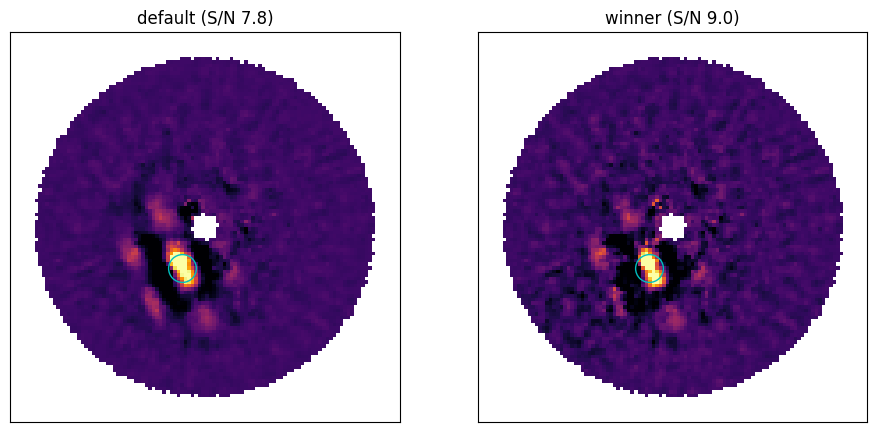

In [8]:
if HAVE_DATA:
    r = results[0]
    print(f"winner: eval {r.winner_index + 1}, validated {r.validated}, injected S/N {r.winner_score:.2f}"
          f"   rolls kept: {r.partitions}")
    print(f"  mode = {r.winner_config['params'].get('mode')}")
    for pid, blk in r.winner_config["per_partition"].items():
        print(f"  {pid}: " + "  ".join(f"{k}={v}" for k, v in blk.items() if k in ("filter", "n_ang", "k_klip")))
    best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
    snr1 = float(metric.per_source(best_clean, None, [PLANET[0]], [PLANET[1]])[0])
    print(f"HIP 65426 b: S/N {snr0:.1f} (default)  ->  {snr1:.1f} (validated winner)")
    fig, ax = plt.subplots(1, 2, figsize=(9.5, 4.4))
    for a, im, t in zip(ax, (res.image, best_clean), (f"default (S/N {snr0:.1f})", f"winner (S/N {snr1:.1f})")):
        v = np.nanpercentile(im[np.isfinite(im)], [2, 99.7])
        a.imshow(im, origin="lower", cmap="inferno", vmin=v[0], vmax=v[1]); a.set_title(t)
        a.plot(xb, yb, "o", mfc="none", mec="c", ms=20); a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()

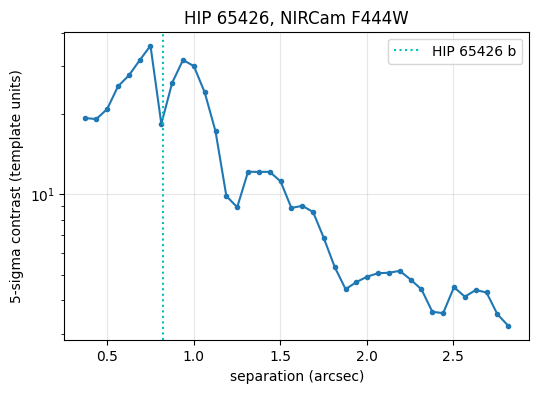

In [9]:
if HAVE_DATA:
    cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
    plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3)
    plt.axvline(PLANET[0], color="c", ls=":", label="HIP 65426 b")
    plt.xlabel("separation (arcsec)")
    plt.ylabel("5-sigma contrast" + ("" if STAR_FLUX else " (template units)"))
    plt.grid(alpha=.3); plt.legend(); plt.title("HIP 65426, NIRCam F444W");

## 5. Notes for real JWST work

* **Preprocessing sets the floor.**  Section 1 is the bare minimum; spaceKLIP's
  `ImageTools` (bad-pixel repair, background subtraction, sub-pixel alignment on the
  diffraction pattern, frame selection) does better, and the optimizer works with whatever
  floor it is given.
* **Photometry.**  Pass an off-axis PSF and the star flux for contrasts in physical units
  rather than template units.
* **Small data sets.**  With four science integrations a single evaluation's score is
  noisy; raise `n_sources` (more injections per evaluation cost nothing — one reduction
  either way) rather than the number of evaluations.
* **What is searched** here is the number of KL modes per roll, the high-pass filter, the
  azimuthal subdivision and pyKLIP's `mode` — the RDI knobs.  Any other backend option
  (`annuli_spacing`, `algo`, `corr_smooth`, …) becomes searchable the same way: add a
  `Param` with that name.

## 6. From a spaceKLIP database

Once you have run spaceKLIP, skip sections 1–2 entirely:
```python
from spaceKLIP import database
db = database.Database(output_dir="spaceklip/")
db.read_jwst_s012_data(datapaths=sorted(glob.glob("spaceklip/IMGPROCESS/*_calints.fits")))
dsets = sk.load_spaceklip(db, key="JWST_NIRCAM_NRCALONG_F444W_MASKRND_MASK335R_SUB320A335R",
                          crop_half=55)          # partition_by="roll" by default
red = sk.make_reducer(dsets, psf_template="offset_psf_F444W.fits", star_flux=F_star)
```
Everything from section 3 on is identical.